# CNN BASED CAR MODEL DETECTION USING CAR HORN SAMPLE

# 1.   AUGMENTATION AND FRAGMENTATION





In [ ]:
# ============================================================

# 🚗 FINAL PIPELINE: CHUNK + AUGMENT + SPEC + MFCC

# ============================================================

# ============================

# 1. INSTALL

# ============================

!pip install librosa audiomentations matplotlib numpy pydub
!apt-get install -y ffmpeg

# ============================

# 2. IMPORTS

# ============================

import os
import re
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from audiomentations import (
    AddGaussianNoise, TimeStretch, PitchShift,
    Shift, Gain, Compose,
)

# ============================

# 3. MOUNT DRIVE

# ============================

from google.colab import drive
drive.mount('/content/drive')

# ============================

# 4. CONFIG

# ============================

CONFIG = {
    "input_dir":  "/content/drive/MyDrive/ML PROJECT",
    "output_dir": "/content/drive/MyDrive/FINAL DATASET",
    "sample_rate": 22050,
    "chunk_duration": 2.0,
    "overlap": 0.5,
}

# ============================

# 5. HELPERS

# ============================

def clean_name(name):
    name = os.path.splitext(name)[0]
    name = re.sub(r'[^a-zA-Z0-9_]', '_', name)
    return name

def load_audio(filepath, sr):
    try:
        audio, _ = librosa.load(filepath, sr=sr, mono=True)
        return audio
    except:
        from pydub import AudioSegment
        import tempfile

        seg = AudioSegment.from_file(filepath)
        with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tmp:
            tmp_path = tmp.name

        seg.export(tmp_path, format="wav")
        audio, _ = librosa.load(tmp_path, sr=sr, mono=True)
        os.remove(tmp_path)
        return audio

def chunk_audio(audio, sr, duration, overlap):
    chunk_samples = int(duration * sr)
    step = int(chunk_samples * (1 - overlap))
    chunks = []

    for start in range(0, len(audio) - chunk_samples, step):
        chunks.append(audio[start:start + chunk_samples])

    return chunks

# ============================

# 6. AUGMENTATIONS

# ============================

def get_augmentations():
    return [
        ("noise",        Compose([AddGaussianNoise(0.002, 0.015, p=1)])),
        ("pitch_up",     Compose([PitchShift(1, 3, p=1)])),
        ("pitch_down",   Compose([PitchShift(-3, -1, p=1)])),
        ("stretch_fast", Compose([TimeStretch(1.1, 1.3, p=1)])),
        ("stretch_slow", Compose([TimeStretch(0.7, 0.9, p=1)])),
        ("gain",         Compose([Gain(-6, 6, p=1)])),
        ("shift",        Compose([Shift(-0.2, 0.2, p=1)])),
    ]

# ============================

# 7. FEATURE GENERATION

# ============================

def create_spectrogram(audio, sr):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel)

    fig = plt.figure(figsize=(2.24, 2.24))
    plt.axis('off')
    librosa.display.specshow(mel_db, sr=sr, cmap='inferno')

    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)

    return img

def create_mfcc(audio, sr):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    fig = plt.figure(figsize=(2.24, 2.24))
    plt.axis('off')
    librosa.display.specshow(mfcc, sr=sr, cmap='viridis')

    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)

    return img

# ============================

# 8. MAIN PIPELINE

# ============================

sr = CONFIG["sample_rate"]
augmentations = get_augmentations()

for file in os.listdir(CONFIG["input_dir"]):

    path = os.path.join(CONFIG["input_dir"], file)

    if not os.path.isfile(path):
        continue

    class_name = clean_name(file)
    class_dir = os.path.join(CONFIG["output_dir"], class_name)
    os.makedirs(class_dir, exist_ok=True)

    print(f"\n🚗 Processing: {file}")

    audio = load_audio(path, sr)
    chunks = chunk_audio(audio, sr, CONFIG["chunk_duration"], CONFIG["overlap"])

    print(f"   Chunks: {len(chunks)}")

    for i, chunk in enumerate(chunks):

        prefix = f"chunk{i:03d}"

        # ===== ORIGINAL =====
        spec = create_spectrogram(chunk, sr)
        mfcc = create_mfcc(chunk, sr)

        plt.imsave(os.path.join(class_dir, f"{prefix}_orig_spec.png"), spec)
        plt.imsave(os.path.join(class_dir, f"{prefix}_orig_mfcc.png"), mfcc)

        # ===== AUGMENTATIONS =====
        for aug_name, aug_fn in augmentations:

            try:
                aug_audio = aug_fn(samples=chunk.copy(), sample_rate=sr)

                spec_aug = create_spectrogram(aug_audio, sr)
                mfcc_aug = create_mfcc(aug_audio, sr)

                plt.imsave(os.path.join(class_dir, f"{prefix}_{aug_name}_spec.png"), spec_aug)
                plt.imsave(os.path.join(class_dir, f"{prefix}_{aug_name}_mfcc.png"), mfcc_aug)

            except Exception:
                print(f"⚠️ Skipped augmentation: {aug_name}")

print("\n🎉 DONE! Full dataset ready!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🚗 Processing: nexon.m4a
   Chunks: 10

🚗 Processing: curvv.ev.m4a
   Chunks: 10

🚗 Processing: punch.m4a
   Chunks: 9

🚗 Processing: taigun.m4a
   Chunks: 10

🚗 Processing: carens.m4a
   Chunks: 3

🚗 Processing: vitara breeza.m4a
   Chunks: 10

🚗 Processing: dzire.m4a
   Chunks: 10

🚗 Processing: waganr.m4a
   Chunks: 9

🚗 Processing: alto.m4a
   Chunks: 9

🚗 Processing: activa 6g.m4a
   Chunks: 9

🚗 Processing: honda unicorn.m4a
   Chunks: 10

🚗 Processing: alcazar.m4a
   Chunks: 10

🚗 Processing: i20.m4a
   Chunks: 10

🚗 Processing: grandi10nios.m4a
   Chunks: 9

🚗 Processing: exter.m4a
   Chunks: 9

🚗 Processing: Venue car.m4a
   Chun

# 2.   DATA SPLITTING



In [ ]:
import os
import shutil
import random

# ============================

# PATHS

# ============================

source_dir = "/content/drive/MyDrive/FINAL DATASET"
base_dir   = "/content/drive/MyDrive/dataset"

train_dir = os.path.join(base_dir, "train")
val_dir   = os.path.join(base_dir, "val")
test_dir  = os.path.join(base_dir, "test")

# ============================

# DELETE OLD DATASET

# ============================

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

# ============================

# CREATE FOLDERS

# ============================

for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

print("🚀 Splitting dataset...")

# ============================

# SPLIT LOOP

# ============================

for class_name in os.listdir(source_dir):

    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [img for img in os.listdir(class_path) if img.endswith(".png")]
    random.shuffle(images)

    total = len(images)

    # 70-15-15 split
    train_count = int(0.7 * total)
    val_count   = int(0.15 * total)

    train_imgs = images[:train_count]
    val_imgs   = images[train_count:train_count + val_count]
    test_imgs   = images[train_count + val_count:]

    # ============================
    # PRINT EXACT FORMAT
    # ============================
    print(f"{class_name:<15} total: {total} → {len(train_imgs)} train | {len(val_imgs)} val | {len(test_imgs)} test")

    # ============================
    # COPY FILES
    # ============================
    for split_name, split_imgs in zip(
        ["train", "val", "test"],
        [train_imgs, val_imgs, test_imgs]
    ):
        split_class_dir = os.path.join(base_dir, split_name, class_name)
        os.makedirs(split_class_dir, exist_ok=True)

        for img in split_imgs:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy(src, dst)

print("\n✅ Dataset split completed successfully!")

🚀 Splitting dataset...
nexon           total: 160 → 112 train | 24 val | 24 test
curvv_ev        total: 160 → 112 train | 24 val | 24 test
punch           total: 144 → 100 train | 21 val | 23 test
taigun          total: 160 → 112 train | 24 val | 24 test
carens          total: 48 → 33 train | 7 val | 8 test
vitara_breeza   total: 160 → 112 train | 24 val | 24 test
dzire           total: 160 → 112 train | 24 val | 24 test
waganr          total: 144 → 100 train | 21 val | 23 test
alto            total: 144 → 100 train | 21 val | 23 test
activa_6g       total: 144 → 100 train | 21 val | 23 test
honda_unicorn   total: 160 → 112 train | 24 val | 24 test
alcazar         total: 160 → 112 train | 24 val | 24 test
i20             total: 160 → 112 train | 24 val | 24 test
grandi10nios    total: 144 → 100 train | 21 val | 23 test
exter           total: 144 → 100 train | 21 val | 23 test
Venue_car       total: 144 → 100 train | 21 val | 23 test
Pulsar_150      total: 144 → 100 train | 21 val | 23 

# 3. GOOGLENET MODEL



In [ ]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

# ============================
# DEVICE
# ============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True  # speeds up fixed-size input training

# ============================
# PATHS
# ============================
train_dir = "/content/drive/MyDrive/dataset/train"
val_dir   = "/content/drive/MyDrive/dataset/val"
test_dir  = "/content/drive/MyDrive/dataset/test"

# ============================
# TRANSFORMS
# ============================
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ============================
# DATASET
# ============================
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data   = datasets.ImageFolder(val_dir, transform=val_test_transform)
test_data  = datasets.ImageFolder(test_dir, transform=val_test_transform)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)
print("Number of classes:", num_classes)

# Colab usually works well with 2 or 4 workers
num_workers = min(4, os.cpu_count())

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
    persistent_workers=True if num_workers > 0 else False
)

# ============================
# MODEL (GOOGLENET)
# ============================
# aux_logits=False makes output simpler and reduces overhead
weights = models.GoogLeNet_Weights.DEFAULT
model = models.googlenet(weights=weights, aux_logits=True) # Changed from False to True

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Replace final classification layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)

# ============================
# LOSS + OPTIMIZER
# ============================
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Optional scheduler for a bit better convergence without extra epochs
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

epochs = 20

# Mixed precision speeds up training on Colab GPU
scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))

# ============================
# TRAINING LOOP
# ============================
for epoch in range(epochs):
    start_time = time.time()

    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            # Extract main logits if aux_logits is True
            if isinstance(outputs, models.GoogLeNetOutputs):
                outputs = outputs.logits
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    scheduler.step()

    train_loss = running_loss / len(train_data)
    train_acc = 100 * train_correct / train_total

    # ========================
    # VALIDATION
    # ========================
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
                outputs = model(images)
                # Extract main logits if aux_logits is True
                if isinstance(outputs, models.GoogLeNetOutputs):
                    outputs = outputs.logits
                loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_data)
    val_acc = 100 * val_correct / val_total
    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Time: {epoch_time:.1f}s")

# ============================
# TESTING
# ============================
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
            outputs = model(images)
            # Extract main logits if aux_logits is True
            if isinstance(outputs, models.GoogLeNetOutputs):
                outputs = outputs.logits

        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

print(f"\nFINAL TEST ACCURACY: {100 * test_correct / test_total:.2f}%")


Using device: cuda
GPU: Tesla T4
Classes: ['Activa_5g', 'Glamour_1', 'Pulsar_150', 'Pulsar_N150', 'RE', 'Splendor_', 'TVS_Ronin_', 'Venue_car', 'XUV_3X0', 'activa_6g', 'alcazar', 'alto', 'baleno', 'carens', 'curvv_ev', 'dzire', 'exter', 'glamour', 'grandi10nios', 'honda_unicorn', 'i20', 'nexon', 'punch', 'taigun', 'vitara_breeza', 'waganr']
Number of classes: 26


/usr/local/lib/python3.12/dist-packages/torchvision/models/googlenet.py:341: UserWarning: auxiliary heads in the pretrained googlenet model are NOT pretrained, so make sure to train them
  warnings.warn(
/tmp/ipykernel_1145/4220576546.py:109: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type == "cuda"))
/tmp/ipykernel_1145/4220576546.py:128: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):
/tmp/ipykernel_1145/4220576546.py:163: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):


Epoch [1/20] Train Loss: 2.9897 | Train Acc: 21.09% | Val Loss: 2.6792 | Val Acc: 36.06% | Time: 292.0s
Epoch [2/20] Train Loss: 2.3972 | Train Acc: 49.04% | Val Loss: 2.1408 | Val Acc: 60.21% | Time: 15.4s
Epoch [3/20] Train Loss: 1.9708 | Train Acc: 62.94% | Val Loss: 1.7876 | Val Acc: 67.32% | Time: 15.3s
Epoch [4/20] Train Loss: 1.6748 | Train Acc: 70.96% | Val Loss: 1.5632 | Val Acc: 70.52% | Time: 15.1s
Epoch [5/20] Train Loss: 1.4826 | Train Acc: 72.47% | Val Loss: 1.3775 | Val Acc: 73.53% | Time: 15.2s
Epoch [6/20] Train Loss: 1.3304 | Train Acc: 75.44% | Val Loss: 1.2368 | Val Acc: 77.80% | Time: 15.1s
Epoch [7/20] Train Loss: 1.1924 | Train Acc: 77.97% | Val Loss: 1.1403 | Val Acc: 79.93% | Time: 15.2s
Epoch [8/20] Train Loss: 1.1295 | Train Acc: 79.44% | Val Loss: 1.0944 | Val Acc: 79.75% | Time: 15.3s
Epoch [9/20] Train Loss: 1.1002 | Train Acc: 80.94% | Val Loss: 1.0953 | Val Acc: 79.75% | Time: 15.5s
Epoch [10/20] Train Loss: 1.0966 | Train Acc: 80.75% | Val Loss: 1.0786 

/tmp/ipykernel_1145/4220576546.py:197: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type == "cuda")):



FINAL TEST ACCURACY: 80.68%


In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/car_model.pth")
print("✅ Model saved successfully!")

✅ Model saved successfully!


# RESNET

In [ ]:
# ============================
# IMPORTS
# ============================

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

# ============================
# DEVICE
# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ============================
# TRANSFORMS (VERY IMPORTANT)
# ============================

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# DATASET (LOCAL PATH)
# ============================

train_path = "/content/dataset/train"
val_path   = "/content/dataset/val"
test_path  = "/content/dataset/test"

train_data = datasets.ImageFolder(train_path, transform=train_transform)
val_data   = datasets.ImageFolder(val_path, transform=val_test_transform)
test_data  = datasets.ImageFolder(test_path, transform=val_test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data, batch_size=32, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_data, batch_size=32, num_workers=2, pin_memory=True)

num_classes = len(train_data.classes)
print("Classes:", train_data.classes)

# ============================
# MODEL (RESNET50)
# ============================

model = models.resnet50(pretrained=True)

# Freeze early layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze deeper layers
for param in model.layer3.parameters():
    param.requires_grad = True

for param in model.layer4.parameters():
    param.requires_grad = True

# Replace final layer
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model = model.to(device)

# ============================
# LOSS + OPTIMIZER
# ============================

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-4},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3}
])

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=2
)

# ============================
# TRAINING
# ============================

epochs = 20
best_val_acc = 0
patience = 5
counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Training Loss: {total_loss:.4f}")

    # ========================
    # VALIDATION
    # ========================

    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Validation Accuracy: {val_acc:.2f}%")

    scheduler.step(val_acc)

    # ========================
    # SAVE BEST MODEL
    # ========================

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/content/best_model.pth")
        print("✅ Best model saved!")
        counter = 0
    else:
        counter += 1

    # ========================
    # EARLY STOPPING
    # ========================

    if counter >= patience:
        print("⛔ Early stopping triggered")
        break

# ============================
# TESTING
# ============================

print("\nLoading best model...")
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

correct, total = 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\n🔥 FINAL TEST ACCURACY: {100 * correct / total:.2f}%")

Using device: cuda
Classes: ['Activa_5g', 'Glamour_1', 'Pulsar_150', 'Pulsar_N150', 'RE', 'Splendor_', 'TVS_Ronin_', 'Venue_car', 'XUV_3X0', 'activa_6g', 'alcazar', 'alto', 'baleno', 'carens', 'curvv_ev', 'dzire', 'exter', 'glamour', 'grandi10nios', 'honda_unicorn', 'i20', 'nexon', 'punch', 'taigun', 'vitara_breeza', 'waganr']


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 133MB/s]



Epoch 1/20
Training Loss: 173.2895
Validation Accuracy: 75.31%
✅ Best model saved!

Epoch 2/20
Training Loss: 31.6570
Validation Accuracy: 96.09%
✅ Best model saved!

Epoch 3/20
Training Loss: 13.9657
Validation Accuracy: 95.91%

Epoch 4/20
Training Loss: 8.8352
Validation Accuracy: 96.45%
✅ Best model saved!

Epoch 5/20
Training Loss: 8.2245
Validation Accuracy: 96.09%

Epoch 6/20
Training Loss: 7.0244
Validation Accuracy: 96.63%
✅ Best model saved!

Epoch 7/20
Training Loss: 2.9143
Validation Accuracy: 98.58%
✅ Best model saved!

Epoch 8/20
Training Loss: 3.9542
Validation Accuracy: 97.16%

Epoch 9/20
Training Loss: 4.8354
Validation Accuracy: 97.16%

Epoch 10/20
Training Loss: 4.3355
Validation Accuracy: 98.22%

Epoch 11/20
Training Loss: 1.4461
Validation Accuracy: 98.76%
✅ Best model saved!

Epoch 12/20
Training Loss: 1.2211
Validation Accuracy: 98.93%
✅ Best model saved!

Epoch 13/20
Training Loss: 0.5324
Validation Accuracy: 98.93%

Epoch 14/20
Training Loss: 0.5363
Validation 

In [ ]:
torch.save(model.state_dict(), "/content/drive/MyDrive/best_model.pth")

# 4. PREDICTION

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms, datasets, models
import os

# ============================

# DEVICE

# ============================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================

# LOAD CLASS NAMES

# ============================

train_data = datasets.ImageFolder("/content/drive/MyDrive/dataset/train")
class_names = train_data.classes
num_classes = len(class_names)

# ============================

# TRANSFORM

# ============================

transform = transforms.Compose([
transforms.Resize((224, 224)),
transforms.ToTensor(),
])

# ============================

# LOAD MODEL

# ============================

# Initialize model with pretrained=True to include auxiliary heads
# to match the saved state_dict
model = models.googlenet(pretrained=True)

# Replace the final classification layer to match the number of classes
model.fc = nn.Linear(model.fc.in_features, num_classes)

# load weights
model_path = "/content/drive/MyDrive/car_model.pth"

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    print("✅ Model loaded successfully")
else:
    print("❌ Model not found! Check path")

model = model.to(device)
model.eval()

# ============================

# FEATURE FUNCTIONS

# ============================

def create_spectrogram(audio, sr):
    mel = librosa.feature.melspectrogram(y=audio, sr=sr)
    mel_db = librosa.power_to_db(mel)

    fig = plt.figure(figsize=(2.24, 2.24))
    plt.axis('off')
    librosa.display.specshow(mel_db, sr=sr, cmap='inferno')

    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)

    return img

def create_mfcc(audio, sr):
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40)

    fig = plt.figure(figsize=(2.24, 2.24))
    plt.axis('off')
    librosa.display.specshow(mfcc, sr=sr, cmap='viridis')

    fig.canvas.draw()
    img = np.asarray(fig.canvas.buffer_rgba())[:, :, :3]
    plt.close(fig)

    return img

# ============================

# PREDICTION FUNCTION

# ============================

def predict_audio(file_path):

    sr = 22050
    audio, _ = librosa.load(file_path, sr=sr)

    chunk_size = int(2.0 * sr)
    predictions = []

    print("\n🔍 Processing audio...")

    for i in range(0, len(audio) - chunk_size + 1, chunk_size):

        chunk = audio[i:i + chunk_size]

        # create features
        spec = create_spectrogram(chunk, sr)
        mfcc = create_mfcc(chunk, sr)

        for img in [spec, mfcc]:

            img = Image.fromarray(img.astype('uint8'))
            img = transform(img).unsqueeze(0).to(device)

            with torch.no_grad():
                outputs = model(img)

                if isinstance(outputs, tuple):
                    outputs = outputs[0]

                probs = F.softmax(outputs, dim=1)
                confidence, pred = torch.max(probs, 1)

            predictions.append((pred.item(), confidence.item()))

    if not predictions:
        print("❌ No valid audio chunks")
        return

    # ============================
    # CONFIDENCE FILTER
    # ============================
    CONF_THRESHOLD = 0.7

    valid_preds = [p for p, conf in predictions if conf > CONF_THRESHOLD]

    if len(valid_preds) == 0:
        print("❌ Invalid / Unknown sound")
        return

    # ============================
    # MAJORITY VOTING
    # ============================
    final_pred = max(set(valid_preds), key=valid_preds.count)

    print("\n✅ Detected Car:", class_names[final_pred])

# ============================

# RUN

# ============================

predict_audio("/content/drive/MyDrive/test.m4a")

✅ Model loaded successfully


/tmp/ipykernel_4764/3694964195.py:108: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, _ = librosa.load(file_path, sr=sr)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



🔍 Processing audio...

✅ Detected Car: exter


In [ ]:
# ============================
# INSTALL
# ============================
!pip install librosa

# ============================
# IMPORTS
# ============================
import torch
import torch.nn as nn
from torchvision import transforms, models, datasets
from PIL import Image
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# LOAD CLASS NAMES
# ============================
train_path = "/content/drive/MyDrive/dataset/train"
train_data = datasets.ImageFolder(train_path)
class_names = train_data.classes

print("Classes:", class_names)
print("Total classes:", len(class_names))

# ============================
# LOAD MODEL
# ============================
model = models.resnet50(pretrained=False)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, len(class_names))
)

model.load_state_dict(torch.load("/content/drive/MyDrive/best_model.pth", map_location=device))
model = model.to(device)
model.eval()

print("✅ Model loaded!")

# ============================
# TRANSFORM
# ============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# AUDIO → SPECTROGRAM (ROBUST)
# ============================
def audio_to_spectrogram(audio_path, save_path="/content/temp.png"):
    y, sr = librosa.load(audio_path, sr=22050)

    # 🔹 FIX 1: Make fixed length (e.g., 3 sec)
    max_len = 3 * sr
    if len(y) > max_len:
        y = y[:max_len]
    else:
        y = np.pad(y, (0, max_len - len(y)))

    # 🔹 FIX 2: Normalize audio
    y = y / np.max(np.abs(y) + 1e-6)

    # 🔹 Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)

    plt.figure(figsize=(3,3))
    librosa.display.specshow(S_dB, sr=sr, cmap='magma')
    plt.axis('off')
    plt.tight_layout(pad=0)

    plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    return save_path

# ============================
# PREDICTION WITH REJECTION
# ============================
def predict_horn(audio_path, threshold=90):
    img_path = audio_to_spectrogram(audio_path)

    image = Image.open(img_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probs = torch.softmax(outputs, dim=1)

    # Top-3 predictions
    top_probs, top_idx = torch.topk(probs, 3)

    top_probs = top_probs.cpu().numpy()[0]
    top_idx = top_idx.cpu().numpy()[0]

    print("\n🎵 Audio:", audio_path)
    print("🔝 Top Predictions:")
    for i in range(3):
        print(f"{class_names[top_idx[i]]} → {top_probs[i]*100:.2f}%")

    best_conf = top_probs[0] * 100
    best_class = class_names[top_idx[0]]

    # 🔥 REJECTION LOGIC
    if best_conf < threshold:
        print("\n❌ Result: INVALID / UNKNOWN AUDIO (Not confident)")
        return "Unknown", best_conf

    # 🔹 Optional: entropy check (uncertainty)
    entropy = -torch.sum(probs * torch.log(probs + 1e-8)).item()
    if entropy > 2.5:
        print("\n❌ Result: UNCERTAIN (High entropy)")
        return "Uncertain", best_conf

    print(f"\n🚗 Final Prediction: {best_class}")
    print(f"📊 Confidence: {best_conf:.2f}%")

    return best_class, best_conf

# ============================
# RUN
# ============================

predict_horn("/content/drive/MyDrive/venue_test.m4a")

Classes: ['Activa_5g', 'Glamour_1', 'Pulsar_150', 'Pulsar_N150', 'RE', 'Splendor_', 'TVS_Ronin_', 'Venue_car', 'XUV_3X0', 'activa_6g', 'alcazar', 'alto', 'baleno', 'carens', 'curvv_ev', 'dzire', 'exter', 'glamour', 'grandi10nios', 'honda_unicorn', 'i20', 'nexon', 'punch', 'taigun', 'vitara_breeza', 'waganr']
Total classes: 26


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded!


/tmp/ipykernel_528/834848602.py:60: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=22050)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)



🎵 Audio: /content/drive/MyDrive/venue_test.m4a
🔝 Top Predictions:
Venue_car → 99.86%
grandi10nios → 0.11%
exter → 0.03%

🚗 Final Prediction: Venue_car
📊 Confidence: 99.86%


('Venue_car', np.float32(99.86291))

# RESULTS

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Classes: ['Activa_5g', 'Glamour_1', 'Pulsar_150', 'Pulsar_N150', 'RE', 'Splendor_', 'TVS_Ronin_', 'Venue_car', 'XUV_3X0', 'activa_6g', 'alcazar', 'alto', 'baleno', 'carens', 'curvv_ev', 'dzire', 'exter', 'glamour', 'grandi10nios', 'honda_unicorn', 'i20', 'nexon', 'punch', 'taigun', 'vitara_breeza', 'waganr']
Total classes: 26


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


✅ Model loaded!

📊 ===== FINAL METRICS =====
Accuracy           : 98.98%
Top-3 Accuracy     : 100.00%
Precision (macro)  : 0.9904
Recall (macro)     : 0.9901
F1-score (macro)   : 0.9901
Precision (weighted): 0.9902
Recall (weighted)  : 0.9898
F1-score (weighted): 0.9899


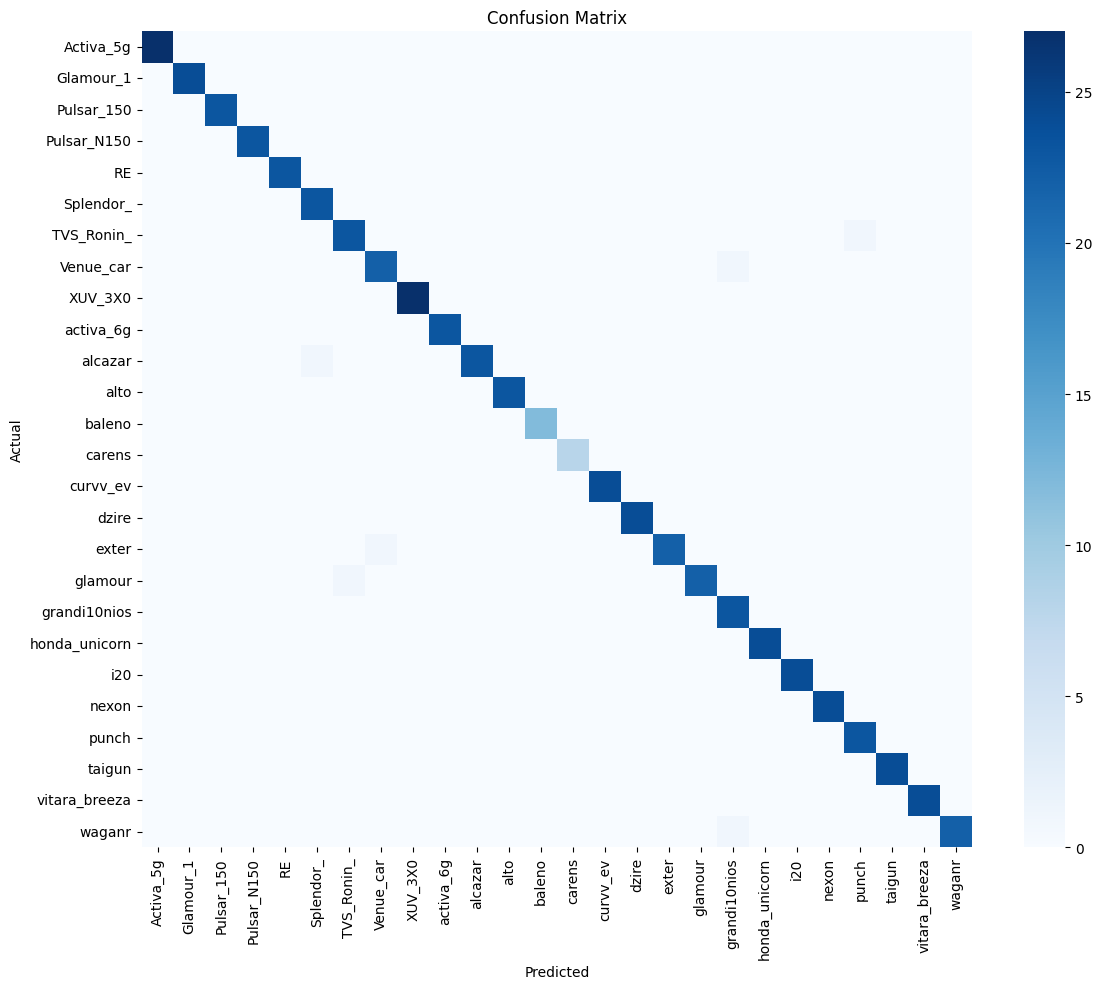


📋 ===== CLASSIFICATION REPORT =====
               precision    recall  f1-score   support

    Activa_5g       1.00      1.00      1.00        27
    Glamour_1       1.00      1.00      1.00        24
   Pulsar_150       1.00      1.00      1.00        23
  Pulsar_N150       1.00      1.00      1.00        23
           RE       1.00      1.00      1.00        23
    Splendor_       0.96      1.00      0.98        23
   TVS_Ronin_       0.96      0.96      0.96        24
    Venue_car       0.96      0.96      0.96        23
      XUV_3X0       1.00      1.00      1.00        27
    activa_6g       1.00      1.00      1.00        23
      alcazar       1.00      0.96      0.98        24
         alto       1.00      1.00      1.00        23
       baleno       1.00      1.00      1.00        12
       carens       1.00      1.00      1.00         8
     curvv_ev       1.00      1.00      1.00        24
        dzire       1.00      1.00      1.00        24
        exter       1.00   

In [ ]:
# ============================
# 1. SETUP
# ============================
from google.colab import drive
drive.mount('/content/drive')

!pip install scikit-learn seaborn

import torch
import torch.nn as nn
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score, accuracy_score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================
# 2. PATHS
# ============================
test_path  = "/content/drive/MyDrive/dataset/test"   # or drive path
model_path = "/content/drive/MyDrive/best_model.pth"

# ============================
# 3. TRANSFORM (same as val/test)
# ============================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# ============================
# 4. DATASET
# ============================
test_data = datasets.ImageFolder(test_path, transform=transform)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=2)

class_names = test_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Total classes:", num_classes)

# ============================
# 5. LOAD MODEL
# ============================
model = models.resnet50(pretrained=False)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, num_classes)
)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("✅ Model loaded!")

# ============================
# 6. EVALUATION LOOP
# ============================
all_preds = []
all_labels = []
top3_correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        # Top-1
        _, preds = torch.max(probs, 1)

        # Top-3
        _, top3 = torch.topk(probs, 3, dim=1)

        # Accumulate
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Top-3 accuracy count
        for i in range(labels.size(0)):
            if labels[i] in top3[i]:
                top3_correct += 1

        total += labels.size(0)

# ============================
# 7. METRICS
# ============================
acc = accuracy_score(all_labels, all_preds)
precision_macro = precision_score(all_labels, all_preds, average='macro')
recall_macro    = recall_score(all_labels, all_preds, average='macro')
f1_macro        = f1_score(all_labels, all_preds, average='macro')

precision_w = precision_score(all_labels, all_preds, average='weighted')
recall_w    = recall_score(all_labels, all_preds, average='weighted')
f1_w        = f1_score(all_labels, all_preds, average='weighted')

top3_acc = top3_correct / total

print("\n📊 ===== FINAL METRICS =====")
print(f"Accuracy           : {acc*100:.2f}%")
print(f"Top-3 Accuracy     : {top3_acc*100:.2f}%")
print(f"Precision (macro)  : {precision_macro:.4f}")
print(f"Recall (macro)     : {recall_macro:.4f}")
print(f"F1-score (macro)   : {f1_macro:.4f}")
print(f"Precision (weighted): {precision_w:.4f}")
print(f"Recall (weighted)  : {recall_w:.4f}")
print(f"F1-score (weighted): {f1_w:.4f}")

# ============================
# 8. CONFUSION MATRIX
# ============================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ============================
# 9. CLASSIFICATION REPORT
# ============================
print("\n📋 ===== CLASSIFICATION REPORT =====")
print(classification_report(all_labels, all_preds, target_names=class_names))

# ============================
# 10. SAVE RESULTS (OPTIONAL)
# ============================
# Save confusion matrix image
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix.png")
plt.close()

print("\n✅ Confusion matrix saved to Drive!")